# Introduction


In other Notebooks, [Gemma 4:E2B Multilangual and Multimodal](https://www.kaggle.com/code/gpreda/gemma-4-e2b-multilangual-and-multimodal), we explored the multi-modal and multi-language capabilities of the most compact model from the new Gemma 4 series, **Gemma 4:E2B**.

While showing good performance for text and text & image inputs, there was one task for which the model didn't show the best performance: object extraction.

We will repeat here the same experiment, with the slightly larger model in the series, **Gemma 4:E4B (it)**.


# Install dependencies and import packages

In [1]:
!pip install -U transformers  -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 117.3 MB/s eta 0:00:00


In [2]:
from time import time
from IPython.display import Markdown
import requests
from PIL import Image
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Model initialization and utils

In [3]:
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")

processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

In [4]:
def colorize_text(text):
    for word, color in zip(["Thinking", "Thinking Process", "Response", "Total time"], ["blue", "red", "green", "magenta"]):
        text = text.replace(f"{word}:", f"\n\n**<font color='{color}'>{word}:</font>**")
    return text
    
def display_response(output, total_time):
    if output.get('thinking'):
        display(Markdown(f"<font color='green'>Thinking</font>"))
        display(Markdown(colorize_text(output["thinking"])))
    if output.get('content'):
        display(Markdown(f"<font color='blue'>Response</font>"))
        display(Markdown(output["content"]))
    display(Markdown(colorize_text(f"Total time: {total_time} sec.")))

# Test with object extraction

We will test with the following image (the same in the previous test):

<img src="https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg"></img>

In [5]:
image_url = "https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is the bounding box for the bike?"}
        ]
    }
]
s_time = time()

text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=1024)

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
output = processor.parse_response(response)

e_time = time()
total_time = round(e_time - s_time, 2)

print(output)
print(f"Total time: {total_time}")

{'role': 'assistant', 'thinking': 'Here are the bounding box detections for the objects in the image:\n- A bicycle is present in the image. I need to provide its coordinates.', 'content': '```json\n[\n  {"box_2d": [477, 187, 949, 650], "label": "the bike"}\n]\n```'}
Total time: 11.27


Let's extract the bboxes and prepare the verification.

[{'box_2d': [477, 187, 949, 650], 'label': 'the bike'}]
<class 'list'>


(np.float64(-0.5), np.float64(735.5), np.float64(502.5), np.float64(-0.5))

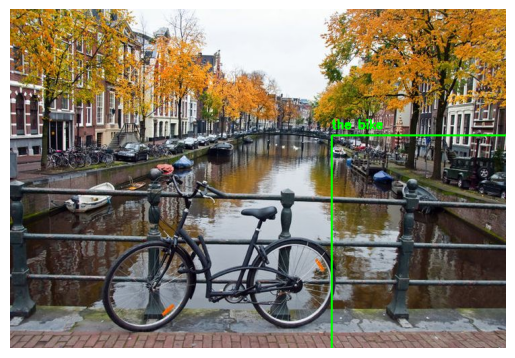

In [6]:
import json
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt


raw = output["content"]

# Remove ```json ... ``` wrappers
clean = re.sub(r"^```json\s*|\s*```$", "", raw.strip(), flags=re.IGNORECASE | re.DOTALL)

bboxes = json.loads(clean)

print(bboxes)
print(type(bboxes))

# Convert PIL → OpenCV (RGB → BGR)
cv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# We are using the bboxes extracted above

# Draw boxes
for item in bboxes:
    x1, y1, x2, y2 = item["box_2d"]
    label = item["label"]

    cv2.rectangle(cv_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        cv_image,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Convert back to RGB for display
rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

# Show in notebook
plt.imshow(rgb_image)
plt.axis("off")


# Conclusions


We tasked the **Gemma 4:E4B (it)** model to extract an object from an image. The predecesor model we tested with (**Gemma 4:E2B (it)**) performed the extraction but with a rather significant error.

In the current test, the quality of the extraction is unfortunatelly not improved.

We still need to understand if the mismatched bounding box is a systematic issue or it is related to the image size, image type, or other element.